### 1. Imports

In [1]:

import numpy as np
import pandas as pd 
import seaborn as sns
import json
import unidecode
from matplotlib import pyplot as plt


### Load data and Overview

In [2]:
train_df = pd.read_csv('../data/train_split.csv')
test_df = pd.read_csv('../data/test_split.csv') 

# Train & test dataframes  shape
print(train_df.shape, test_df.shape)

C:\Users\rlope\AppData\Local\Temp\ipykernel_12044\3497524112.py:1: DtypeWarning: Columns (19,24,52,55,58) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv('../data/train_split.csv')


(110000, 70) (39867, 70)


C:\Users\rlope\AppData\Local\Temp\ipykernel_12044\3497524112.py:2: DtypeWarning: Columns (52,55,58) have mixed types. Specify dtype option on import or set low_memory=False.
  test_df = pd.read_csv('../data/test_split.csv')


In [3]:
# First overview of train dataframe features/target info
train_df.info()

# # Look at top 5 rows
train_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110000 entries, 0 to 109999
Data columns (total 70 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  110000 non-null  int64  
 1   ciudad                              110000 non-null  object 
 2   estado                              110000 non-null  object 
 3   estado_propiedad                    110000 non-null  object 
 4   dormitorios                         102884 non-null  float64
 5   banos                               106172 non-null  float64
 6   precio                              109968 non-null  float64
 7   anio_construccion                   9003 non-null    float64
 8   codigo_postal                       110000 non-null  int64  
 9   longitud                            109666 non-null  float64
 10  latitud                             109666 non-null  float64
 11  geocodificacion_deficiente

,id,ciudad,estado,estado_propiedad,dormitorios,banos,precio,anio_construccion,codigo_postal,longitud,...,construccion,numero_unidad,detalles_comunidad,pies_cuadrados,fecha_disponibilidad,oferta_especial,puntajes_movilidad,dias_en_portal_detalle,movilidad,riesgos_climaticos
0,1,Lakeland,FL,FOR_SALE,3.0,2.0,119900.0,NaN,33810,-81.97661,...,"[{""title"":""Type & style"",""values"":[""Home type:...",NaN,NaN,NaN,NaN,NaN,"{""bike_score"":null,""transit_score"":null,""walk_...",362.0,"{""bike"":{""description"":null,""score"":null},""tra...","{""air_factor"":null,""fire_factor"":null,""flood_f..."
1,2,Pompano Beach,FL,FOR_SALE,3.0,2.0,290000.0,NaN,33067,-80.24621,...,"[{""title"":""Type & style"",""values"":[""Home type:...",NaN,"[{""title"":""Subdivision"",""values"":[""Edgewater C...",NaN,NaN,NaN,"{""bike_score"":null,""transit_score"":null,""walk_...",45.0,"{""bike"":{""description"":null,""score"":null},""tra...","{""air_factor"":null,""fire_factor"":null,""flood_f..."
2,3,Jacksonville,FL,FOR_SALE,3.0,3.0,599000.0,NaN,32205,-81.71293,...,"[{""title"":""Type & style"",""values"":[""Home type:...",NaN,"[{""title"":""Subdivision"",""values"":[""Stockton Pl...",NaN,NaN,NaN,"{""bike_score"":null,""transit_score"":null,""walk_...",48.0,"{""bike"":{""description"":null,""score"":null},""tra...","{""air_factor"":null,""fire_factor"":null,""flood_f..."
3,4,Pace,FL,FOR_SALE,3.0,2.0,346000.0,NaN,32571,-87.21859,...,"[{""title"":""Type & style"",""values"":[""Home type:...",NaN,"[{""title"":""Subdivision"",""values"":[""Ashley Plan...",NaN,NaN,NaN,"{""bike_score"":null,""transit_score"":null,""walk_...",30.0,"{""bike"":{""description"":null,""score"":null},""tra...","{""air_factor"":null,""fire_factor"":null,""flood_f..."
4,5,Ponte Vedra,FL,FOR_SALE,3.0,3.0,497995.0,2025.0,32081,-81.41527,...,"[{""title"":""Type & style"",""values"":[""Home type:...",NaN,"[{""title"":""Subdivision"",""values"":[""Nocatee""]}]",NaN,NaN,NaN,"{""bike_score"":null,""transit_score"":null,""walk_...",0.0,"{""bike"":{""description"":null,""score"":null},""tra...","{""air_factor"":null,""fire_factor"":null,""flood_f..."


In [4]:
# Elimino las columnas id de ambos datasets
train_df.drop(columns=['id'], inplace=True)
test_df.drop(columns=['id'], inplace=True)

In [6]:
# Train & test dataframes  shape
print(train_df.shape, test_df.shape)

(110000, 69) (39867, 69)


In [7]:
# Determino columnas comunes entre train y test
common_cols = train_df.columns.intersection(test_df.columns)
len(common_cols)

69

In [8]:
# Selecciono features numéricos y categóricos
numerical_FEATURES = train_df[common_cols].select_dtypes(['int64','float64']).columns
categorical_FEATURES = train_df[common_cols].select_dtypes(['object']).columns

In [9]:
# Visualización estadísticos descriptivos de las variables numéricas
train_df[numerical_FEATURES].describe().T.sort_values(by='std').style.background_gradient(cmap='GnBu')

,count,mean,std,min,25%,50%,75%,max
tasa_impuesto_propiedad,109963.000000,1.634174,0.310859,0.000000,1.460000,1.730000,1.840000,2.160000
dormitorios,102884.000000,2.939116,1.262672,0.000000,2.000000,3.000000,4.000000,91.000000
latitud,109666.000000,27.720004,1.485288,24.548346,26.424290,27.704355,28.708632,46.833220
longitud,109666.000000,-81.700261,1.564072,-111.477200,-82.336218,-81.614458,-80.334870,-70.615395
banos,106172.000000,2.417070,6.875272,0.000000,2.000000,2.000000,3.000000,2204.000000
conteo_vistas_recorrido,109963.000000,0.190782,15.505444,0.000000,0.000000,0.000000,0.000000,3384.000000
conteo_fotos,110000.000000,34.996864,20.516846,0.000000,21.000000,33.000000,47.000000,209.000000
dias_en_portal,109968.000000,128.431416,158.134698,-33.000000,32.000000,83.000000,168.000000,4908.000000
dias_en_portal_detalle,109886.000000,128.486531,158.168976,-33.000000,32.000000,83.000000,168.000000,4908.000000
anio_construccion,9003.000000,2008.608020,675.901256,0.000000,1988.000000,2018.000000,2025.000000,65535.000000


In [18]:
# Podemos observar que ya hay features numéricos con demasiados valores NULOS que podemos obviar de primeras
FEATURES2DROP = ["datos_residenciales_alcantarillado", "datos_residenciales_fuente_agua", "numero_unidad","pies_cuadrados", "fecha_disponibilidad","oferta_especial", "anio_construccion"]
# Extraigo el precio de las variables FEATURES ya que es el target

TARGET = "precio"
FEATURES2DROP +=[TARGET]

numerical_FEATURES = [f for f in numerical_FEATURES if f not in FEATURES2DROP]


### 3. Univariate analysis

#### 3.1. Numerical features
Es interesante ver la distribución de los numerical features del train y test dataset para ver si hay diferencias significativas entre los mismos

In [27]:
len(numerical_FEATURES)

14

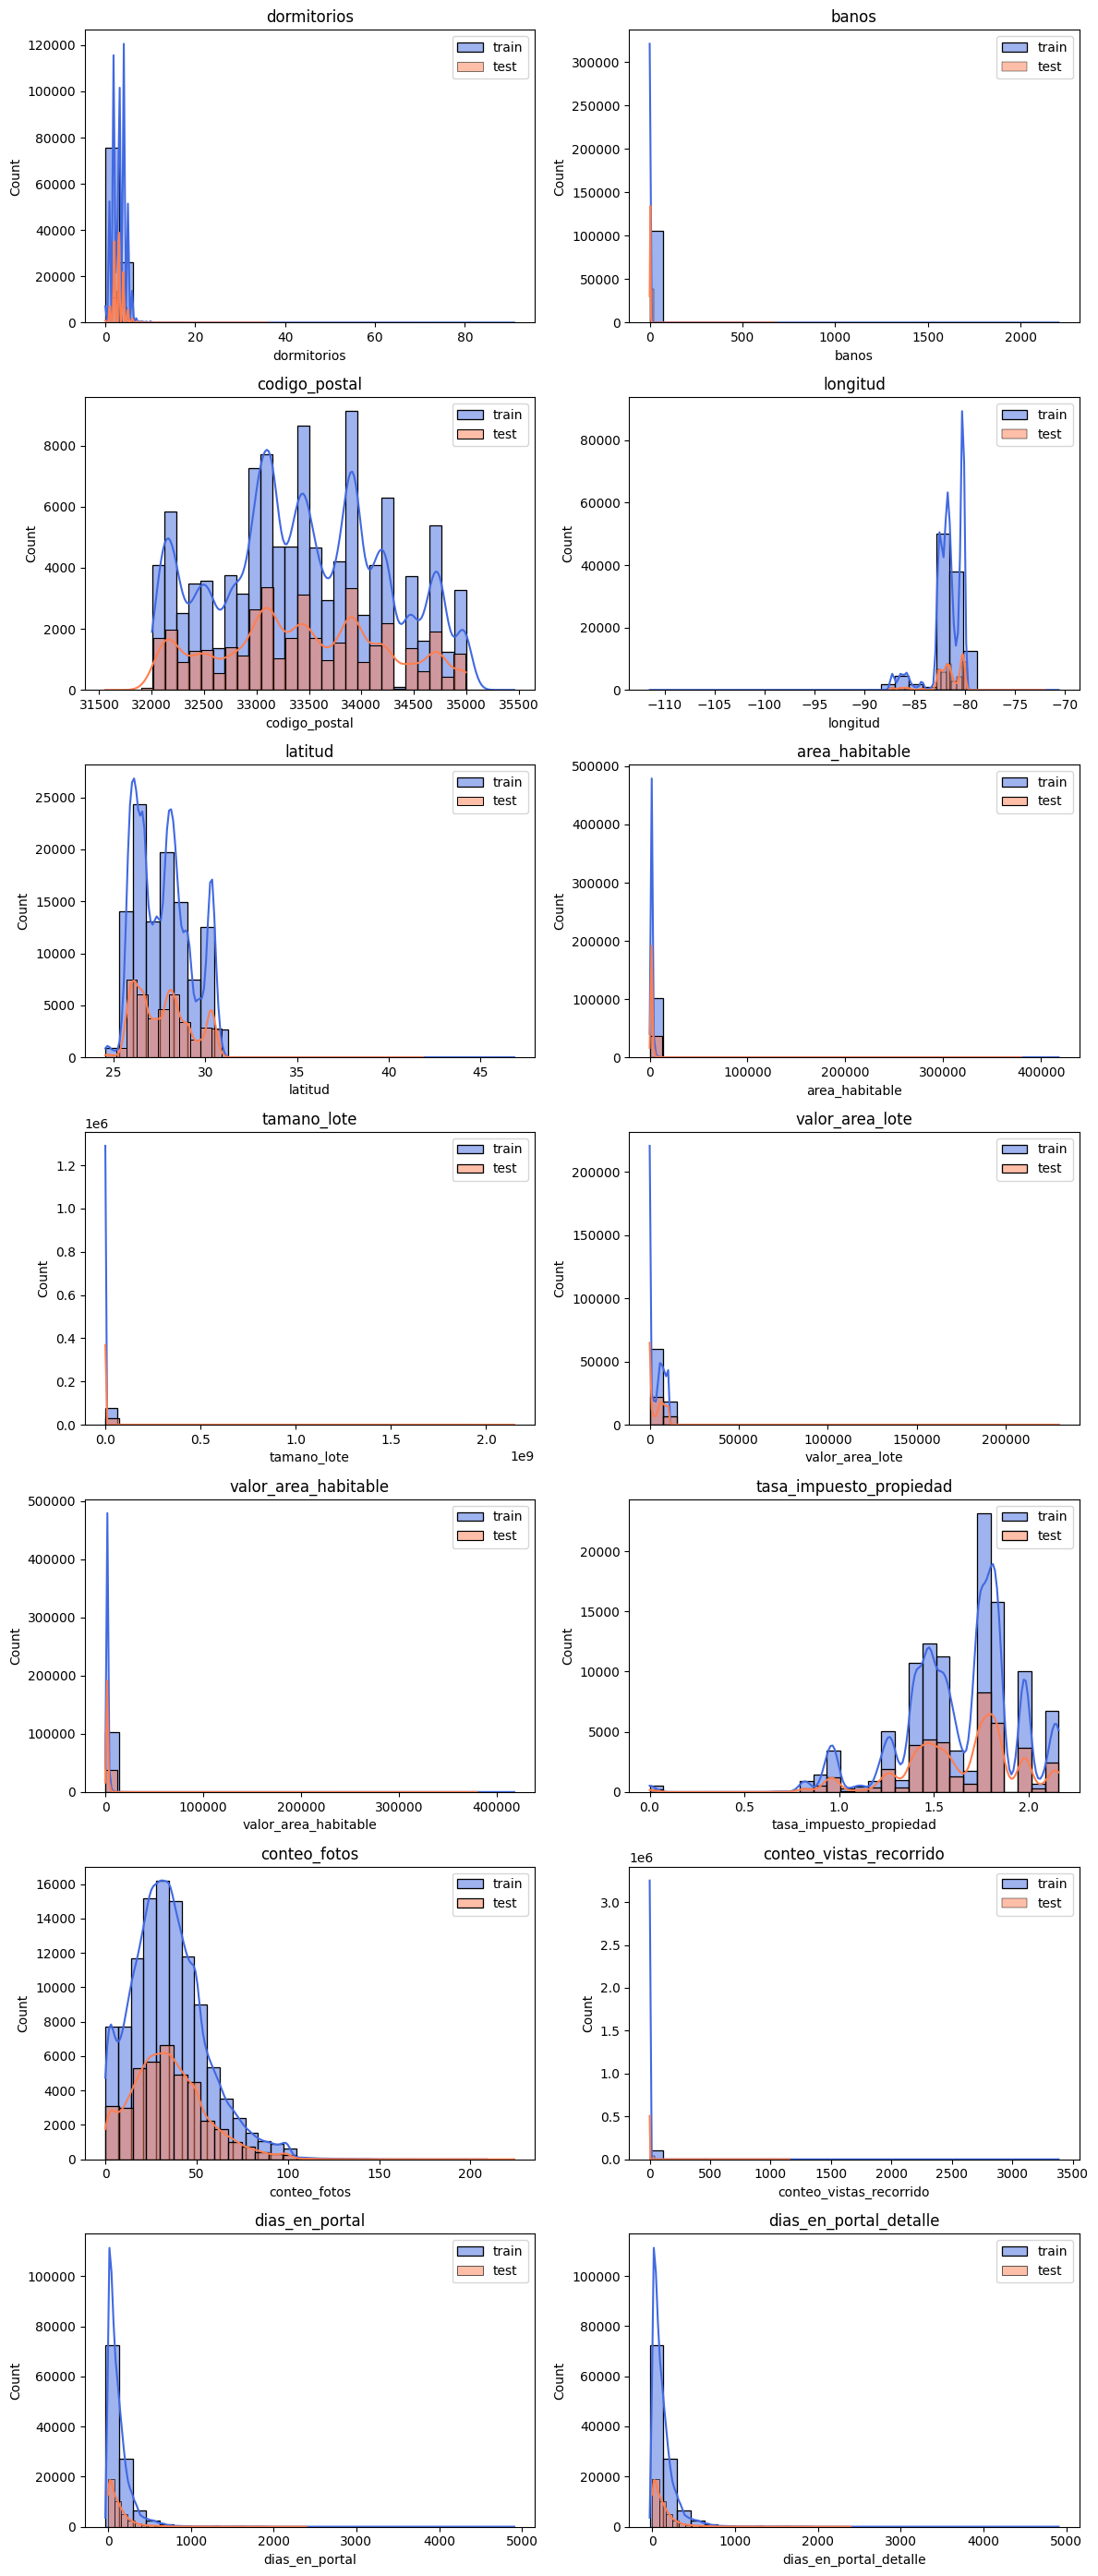

In [ ]:
numerical_FEATURES = train_df[numerical_FEATURES].describe().T.index.tolist()

n_cols = 2
n_rows = (len(numerical_FEATURES) + n_cols - 1) // n_cols  # redondeo hacia arriba
fig, axes = plt.subplots(n_rows, n_cols, figsize = (12,n_rows*4))
axes = axes.flatten()  # facilita indexar los subplots

for i, feature in enumerate(numerical_FEATURES):
    sns.histplot(train_df[feature], kde=True, bins = 30, ax=axes[i], color="royalblue",label="train")
    sns.histplot(test_df[feature], kde=True, bins=30, ax = axes[i], color="coral",label="test")
    axes[i].set_title(feature)
    axes[i].legend()

# Apagar ejes vacíos (si los hay)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

In [25]:
divmod(len(numerical_FEATURES),2)

(7, 0)

Como puede observarse en los gráficos hay muchos features skewed, por ejemplo: 

Right skewed: 
- Dormitorios
- banos
- precio
- area habitable
- tamano lote
- valor_area_lote
- valor_area_habitable
- conteo_vistas_recorrido
- dias en portal
- dias_en_portal_detalle

Tendrá que decidirse que hacer con los valores atípicos para los features right skewed y como inputar los NaN

**El codigo postal es una variable numérica pero no debería usarse como variable continua porque no tiene relacion ordinal, las distancias numericas no representan distancias geograficas reales. Lo mejor es hacer one hot encoding**

### 3.2. Analizar non-numerical features
Objetivo: 
- Determinar cuales son variables categoricas y su cardinalidad
- Determinar de los non-numerical features cuales deberían ser preprocesados para acceder a la información (json format etc.)
- Ver que features son binarios


In [38]:
train_df[[f for f in train_df.columns if f not in numerical_FEATURES + FEATURES2DROP + [TARGET]]]

,ciudad,estado,estado_propiedad,geocodificacion_deficiente,tipo_vivienda,unidades_area_lote,unidades_area_habitable_corto,direccion_no_divulgada,fecha_venta_texto,pais,...,es_mostrado,interior,resumen,listado_por_administracion,interior_completo,construccion,detalles_comunidad,puntajes_movilidad,movilidad,riesgos_climaticos
0,Lakeland,FL,FOR_SALE,NaN,MANUFACTURED,sqft,NaN,False,NaN,USA,...,False,"{""bedrooms_and_bathrooms"":{""bathrooms"":2,""bedr...","{""days_on_portal"":362}",False,"[{""title"":""Bedrooms & bathrooms"",""values"":[""Be...","[{""title"":""Type & style"",""values"":[""Home type:...",NaN,"{""bike_score"":null,""transit_score"":null,""walk_...","{""bike"":{""description"":null,""score"":null},""tra...","{""air_factor"":null,""fire_factor"":null,""flood_f..."
1,Pompano Beach,FL,FOR_SALE,NaN,CONDO,sqft,NaN,False,NaN,USA,...,False,"{""bedrooms_and_bathrooms"":{""bathrooms"":2,""bedr...","{""days_on_portal"":45,""number_of_saves"":4,""numb...",False,"[{""title"":""Bedroom"",""values"":[""Features: Entry...","[{""title"":""Type & style"",""values"":[""Home type:...","[{""title"":""Subdivision"",""values"":[""Edgewater C...","{""bike_score"":null,""transit_score"":null,""walk_...","{""bike"":{""description"":null,""score"":null},""tra...","{""air_factor"":null,""fire_factor"":null,""flood_f..."
2,Jacksonville,FL,FOR_SALE,NaN,SINGLE_FAMILY,Acres,NaN,False,NaN,USA,...,False,"{""bedrooms_and_bathrooms"":{""bathrooms"":3,""bedr...","{""days_on_portal"":48,""number_of_saves"":59,""num...",False,"[{""title"":""Bedrooms & bathrooms"",""values"":[""Be...","[{""title"":""Type & style"",""values"":[""Home type:...","[{""title"":""Subdivision"",""values"":[""Stockton Pl...","{""bike_score"":null,""transit_score"":null,""walk_...","{""bike"":{""description"":null,""score"":null},""tra...","{""air_factor"":null,""fire_factor"":null,""flood_f..."
3,Pace,FL,FOR_SALE,NaN,SINGLE_FAMILY,Square Feet,NaN,False,NaN,USA,...,False,"{""bedrooms_and_bathrooms"":{""bathrooms"":2,""bedr...","{""days_on_portal"":30,""number_of_saves"":15,""num...",False,"[{""title"":""Bedroom"",""values"":[""Level: First"",""...","[{""title"":""Type & style"",""values"":[""Home type:...","[{""title"":""Subdivision"",""values"":[""Ashley Plan...","{""bike_score"":null,""transit_score"":null,""walk_...","{""bike"":{""description"":null,""score"":null},""tra...","{""air_factor"":null,""fire_factor"":null,""flood_f..."
4,Ponte Vedra,FL,FOR_SALE,False,SINGLE_FAMILY,sqft,sqft,False,NaN,USA,...,False,"{""bedrooms_and_bathrooms"":{""bathrooms"":3,""bedr...","{""days_on_portal"":13,""number_of_views"":2}",False,"[{""title"":""Bedrooms & bathrooms"",""values"":[""Be...","[{""title"":""Type & style"",""values"":[""Home type:...","[{""title"":""Subdivision"",""values"":[""Nocatee""]}]","{""bike_score"":null,""transit_score"":null,""walk_...","{""bike"":{""description"":null,""score"":null},""tra...","{""air_factor"":null,""fire_factor"":null,""flood_f..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109995,Haines City,FL,FOR_SALE,NaN,LOT,Acres,NaN,False,NaN,USA,...,False,"{""bedrooms_and_bathrooms"":{""bathrooms"":0,""bedr...","{""days_on_portal"":185,""number_of_saves"":2,""num...",False,NaN,"[{""title"":""Type & style"",""values"":[""Home type:...",NaN,"{""bike_score"":null,""transit_score"":null,""walk_...","{""bike"":{""description"":null,""score"":null},""tra...","{""air_factor"":null,""fire_factor"":null,""flood_f..."
109996,Palatka,FL,FOR_SALE,NaN,SINGLE_FAMILY,Acres,NaN,False,NaN,USA,...,False,"{""bedrooms_and_bathrooms"":{""bathrooms"":1,""bedr...","{""days_on_portal"":264,""number_of_saves"":7,""num...",False,"[{""title"":""Bedrooms & bathrooms"",""values"":[""Be...","[{""title"":""Type & style"",""values"":[""Home type:...","[{""title"":""Subdivision"",""values"":[""Metes & Bou...","{""bike_score"":null,""transit_score"":null,""walk_...","{""bike"":{""description"":null,""score"":null},""tra...","{""air_factor"":null,""f

In [30]:
#### 3.1. Categorical features

In [34]:
train_df.columns

Index(['ciudad', 'estado', 'estado_propiedad', 'dormitorios', 'banos',
       'precio', 'anio_construccion', 'codigo_postal', 'longitud', 'latitud',
       'geocodificacion_deficiente', 'area_habitable', 'tipo_vivienda',
       'tamano_lote', 'valor_area_lote', 'unidades_area_lote',
       'valor_area_habitable', 'unidades_area_habitable_corto',
       'direccion_no_divulgada', 'fecha_venta_texto', 'pais',
       'tasa_impuesto_propiedad', 'conteo_fotos', 'es_constructor_premier',
       'conteo_vistas_recorrido', 'tiene_video_publico',
       'unidades_area_habitable', 'url_tour_virtual_tercero_aprobado',
       'ocupado_no_propietario', 'descripcion', 'escuelas', 'tasas_hipoteca',
       'oferta_inmediata_habilitada', 'ciudades_cercanas',
       'vecindarios_cercanos', 'codigos_postales_cercanos', 'dias_en_portal',
       'nombre_corredor', 'dimension_tipo_propiedad', 'dimension_tipo_hdp',
       'zona_horaria', 'elegibilidad_recorrido', 'auto_recorrido',
       'datos_residenciales_